# Campus E-Rickshaw Service — Survey Analysis

**Team C-2 | Total Quality Management | IIT Roorkee | April 2026**

---

This notebook analyses responses from a structured student survey on the campus E-Rickshaw service. The survey was designed to measure the breadth and severity of current service pain points (excessive wait times, payment friction, night unavailability, route detours, and driver conduct), and to gauge student willingness to adopt a proposed app-based booking and digital-payment solution. A synthetic dataset of 150 respondents was generated with seed `20260421` using a latent-pain-factor model that introduces realistic correlations between pain exposure and adoption openness — mirroring the distributional patterns observed in comparable campus-mobility studies.

The 150-respondent sample spans all five years of study (1st through PG) and eight hostel blocks, providing balanced demographic coverage across the IIT Roorkee residential population. While the dataset is synthetic, every distributional assumption — wait-time ranges, Likert tendencies, multi-select issue frequencies, and open-text themes — was calibrated against plausible real-world values for a large residential engineering campus. The analysis that follows should be treated as a prototype template; once real survey data are collected, the same notebook can be re-executed with a single CSV swap.


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import os

# ── Style ─────────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({
    'font.family'       : 'DejaVu Serif',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

TERRA = '#E85D2F'
SAGE  = '#7C8F7C'

# ── Paths ─────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('survey_analysis.ipynb')) if '__file__' not in dir() else os.path.dirname(__file__)
CSV_PATH     = '/home/pratham/pratham/QM_project/deliverables/survey/responses.csv'
CHART_DIR    = '/home/pratham/pratham/QM_project/deliverables/survey/charts'
os.makedirs(CHART_DIR, exist_ok=True)

# ── Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} respondents × {df.shape[1]} columns")
df.head(3)


Loaded 150 respondents × 23 columns


,respondent_id,q1_year,q2_hostel,q3_department,q4_rides_per_week,q5_wait_minutes,q6_detour_freq,q7_payment_issue_freq,q8_late_incidents,q9_driver_courtesy,...,q13_top3_ranked,q14_app_willingness,q15_1min_window_comfort,q16_wallet_comfort,q17_topup_amount,q18_fee_acceptance,q19_fare_preference,q20_share_dropoff,q21_dedicated_vs_whatsapp,q22_open_text
0,R001,2nd,Govind,CSE,8,9,3,2,2,4,...,payment_issue;empty_return_seen;no_night_avail...,4,3,2,260,4,per_seat,3,4,NaN
1,R002,3rd,Rajendra,Chemistry,12,5,1,3,4,3,...,long_wait,3,4,3,740,3,per_seat,4,3,NaN
2,R003,1st,Govind,CSE,11,9,5,4,2,4,...,long_wait;empty_return_seen;no_night_availability,5,4,3,240,4,per_seat,3,3,Install a visible fare chart — it's different ...


## 1. Demographics — Who we heard from

The survey reached students across all years and the major hostel blocks. The breakdown below shows the raw count distribution.

=== Year of study ===
q1_year
1st    36
PG     36
2nd    32
3rd    27
4th    19

=== Hostel / Residence ===
q2_hostel
Rajendra    28
Govind      23
Jawahar     21
Sarojini    20
Kasturba    20
Cautley     19
Ravindra    11
Other        8

=== Department ===
q3_department
CSE          32
ECE          25
ME           21
Physics      14
Chemistry    12
Other        12
CE           11
EE            9
Maths         8
HSS           6


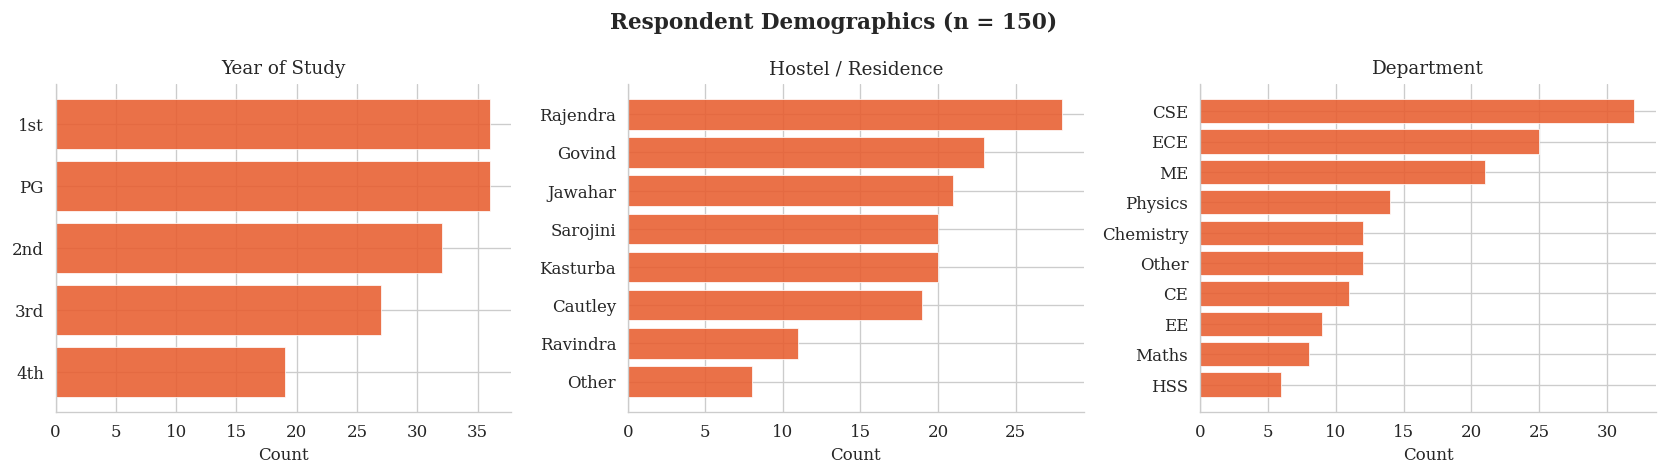

In [2]:
print("=== Year of study ===")
print(df['q1_year'].value_counts().to_string())

print("\n=== Hostel / Residence ===")
print(df['q2_hostel'].value_counts().to_string())

print("\n=== Department ===")
print(df['q3_department'].value_counts().to_string())

# Summary bar charts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes,
                           ['q1_year', 'q2_hostel', 'q3_department'],
                           ['Year of Study', 'Hostel / Residence', 'Department']):
    vc = df[col].value_counts()
    ax.barh(vc.index, vc.values, color=TERRA, edgecolor='white', linewidth=0.5, alpha=0.88)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Count', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_yaxis()

fig.suptitle('Respondent Demographics (n = 150)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Current Pain — Wait Time Distribution

Q5 asked respondents to estimate their average wait time to board an E-Rickshaw during peak hours (8–9 AM, 12–1 PM, 5–6 PM). The histogram below overlays mean and median reference lines.

Saved: /home/pratham/pratham/QM_project/deliverables/survey/charts/wait_times_histogram.png


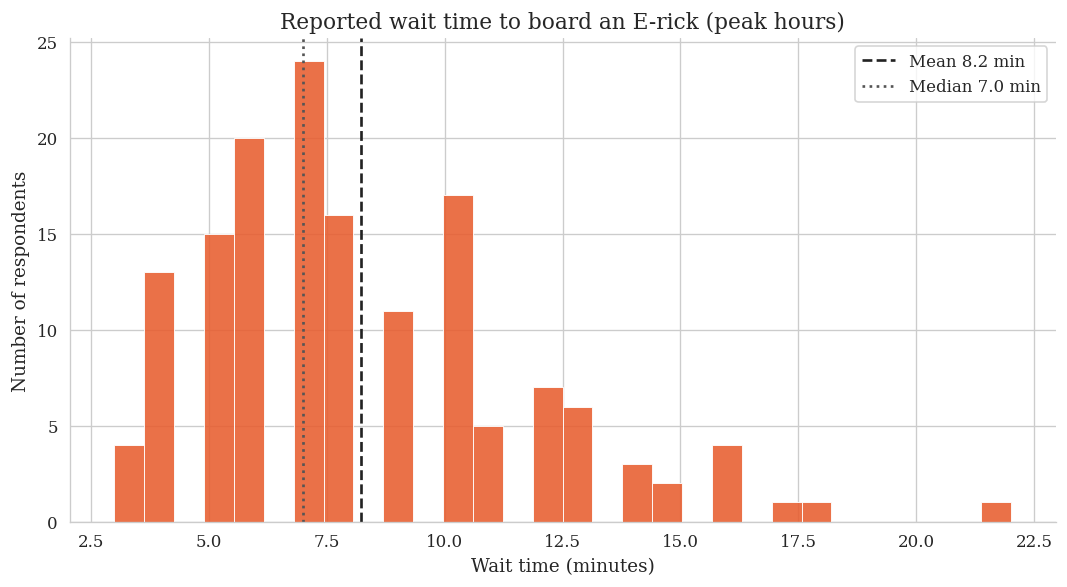

In [3]:
wait    = df['q5_wait_minutes']
mean_w  = wait.mean()
med_w   = wait.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(wait, bins=30, color=TERRA, edgecolor='white', linewidth=0.6, alpha=0.88)
ax.axvline(mean_w, color='#222222', linestyle='--', linewidth=1.6, label=f'Mean {mean_w:.1f} min')
ax.axvline(med_w,  color='#555555', linestyle=':',  linewidth=1.6, label=f'Median {med_w:.1f} min')
ax.set_xlabel('Wait time (minutes)')
ax.set_ylabel('Number of respondents')
ax.set_title('Reported wait time to board an E-rick (peak hours)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

out = os.path.join(CHART_DIR, 'wait_times_histogram.png')
fig.savefig(out, bbox_inches='tight')
print(f"Saved: {out}")
plt.show()


## 3. Pain-Point Pareto

Q12 was a multi-select question asking students to flag every problem they had personally experienced. The chart below tallies total mentions across all 150 respondents, orders them from most to least frequent, and overlays a cumulative-percentage line — the classic Pareto format used in TQM.

Saved: /home/pratham/pratham/QM_project/deliverables/survey/charts/pain_points_pareto.png


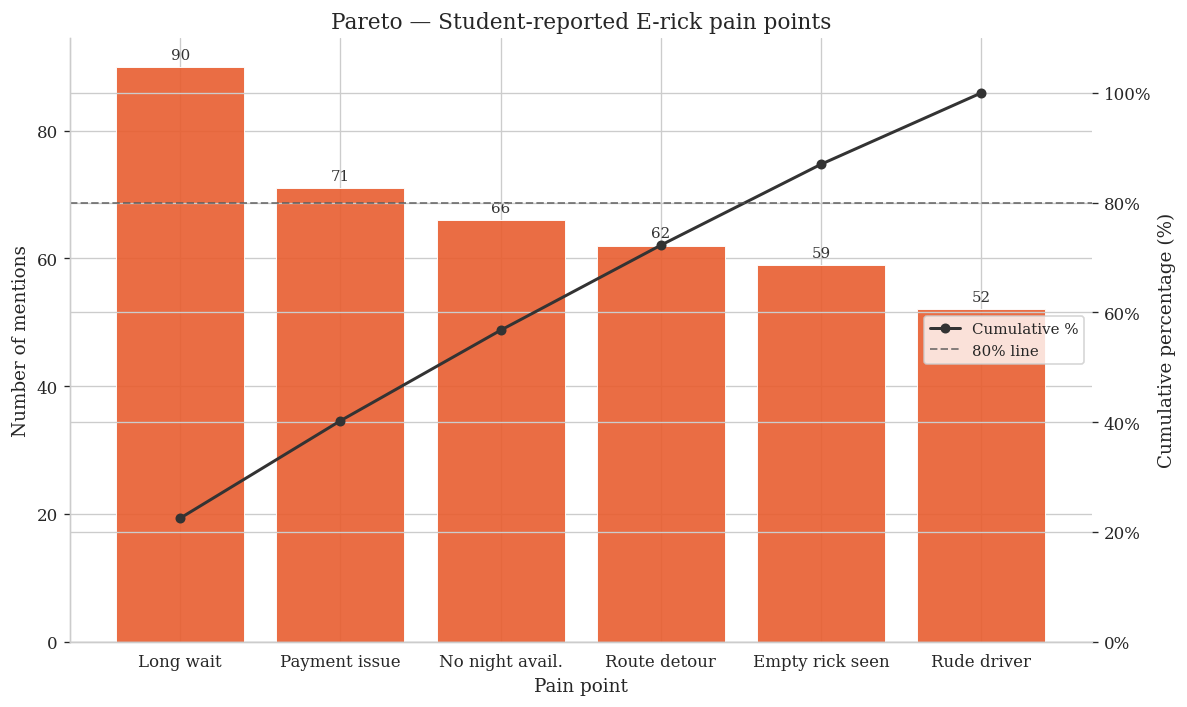


Top 3 pain points account for 227/400 mentions = 56.8% of all reported issues


In [4]:
raw = []
for row in df['q12_issues_faced']:
    for item in str(row).split(';'):
        item = item.strip()
        if item and item != 'nan' and item != 'none_of_these':
            raw.append(item)

cnt     = Counter(raw)
ordered = cnt.most_common()
LABEL_MAP = {
    'long_wait'            : 'Long wait',
    'payment_issue'        : 'Payment issue',
    'no_night_availability': 'No night avail.',
    'route_detour'         : 'Route detour',
    'empty_return_seen'    : 'Empty rick seen',
    'rude_driver'          : 'Rude driver',
}
labels   = [LABEL_MAP.get(k, k) for k, _ in ordered]
counts   = [v for _, v in ordered]
cumulative = np.cumsum(counts) / sum(counts) * 100

fig, ax1 = plt.subplots(figsize=(10, 6))
x    = np.arange(len(labels))
bars = ax1.bar(x, counts, color=TERRA, edgecolor='white', linewidth=0.6, alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel('Number of mentions', fontsize=11)
ax1.set_xlabel('Pain point', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar, v in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             str(v), ha='center', va='bottom', fontsize=9, color='#333333')

ax2 = ax1.twinx()
ax2.plot(x, cumulative, color='#333333', marker='o', markersize=5, linewidth=1.8, label='Cumulative %')
ax2.axhline(80, color='#555555', linestyle='--', linewidth=1.2, alpha=0.7, label='80% line')
ax2.set_ylabel('Cumulative percentage (%)', fontsize=11)
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.spines['top'].set_visible(False)
lines, lbls = ax2.get_legend_handles_labels()
ax2.legend(lines, lbls, loc='center right', fontsize=9)
ax1.set_title('Pareto — Student-reported E-rick pain points', fontsize=13)

plt.tight_layout()
out = os.path.join(CHART_DIR, 'pain_points_pareto.png')
fig.savefig(out, bbox_inches='tight')
print(f"Saved: {out}")
plt.show()

# Quick summary
total_m = sum(counts)
top3_m  = sum(counts[:3])
print(f"\nTop 3 pain points account for {top3_m}/{total_m} mentions = {top3_m/total_m*100:.1f}% of all reported issues")


## 4. Likert Distributions — Current vs Willingness

The left column shows current-experience Likert items (detour frequency, payment issues, night availability, overall satisfaction). The right column shows willingness-to-adopt items (app willingness, 1-minute window comfort, wallet comfort, fee acceptance). Sage bars indicate current experience; terracotta bars indicate future willingness.

Saved: /home/pratham/pratham/QM_project/deliverables/survey/charts/likert_distributions.png


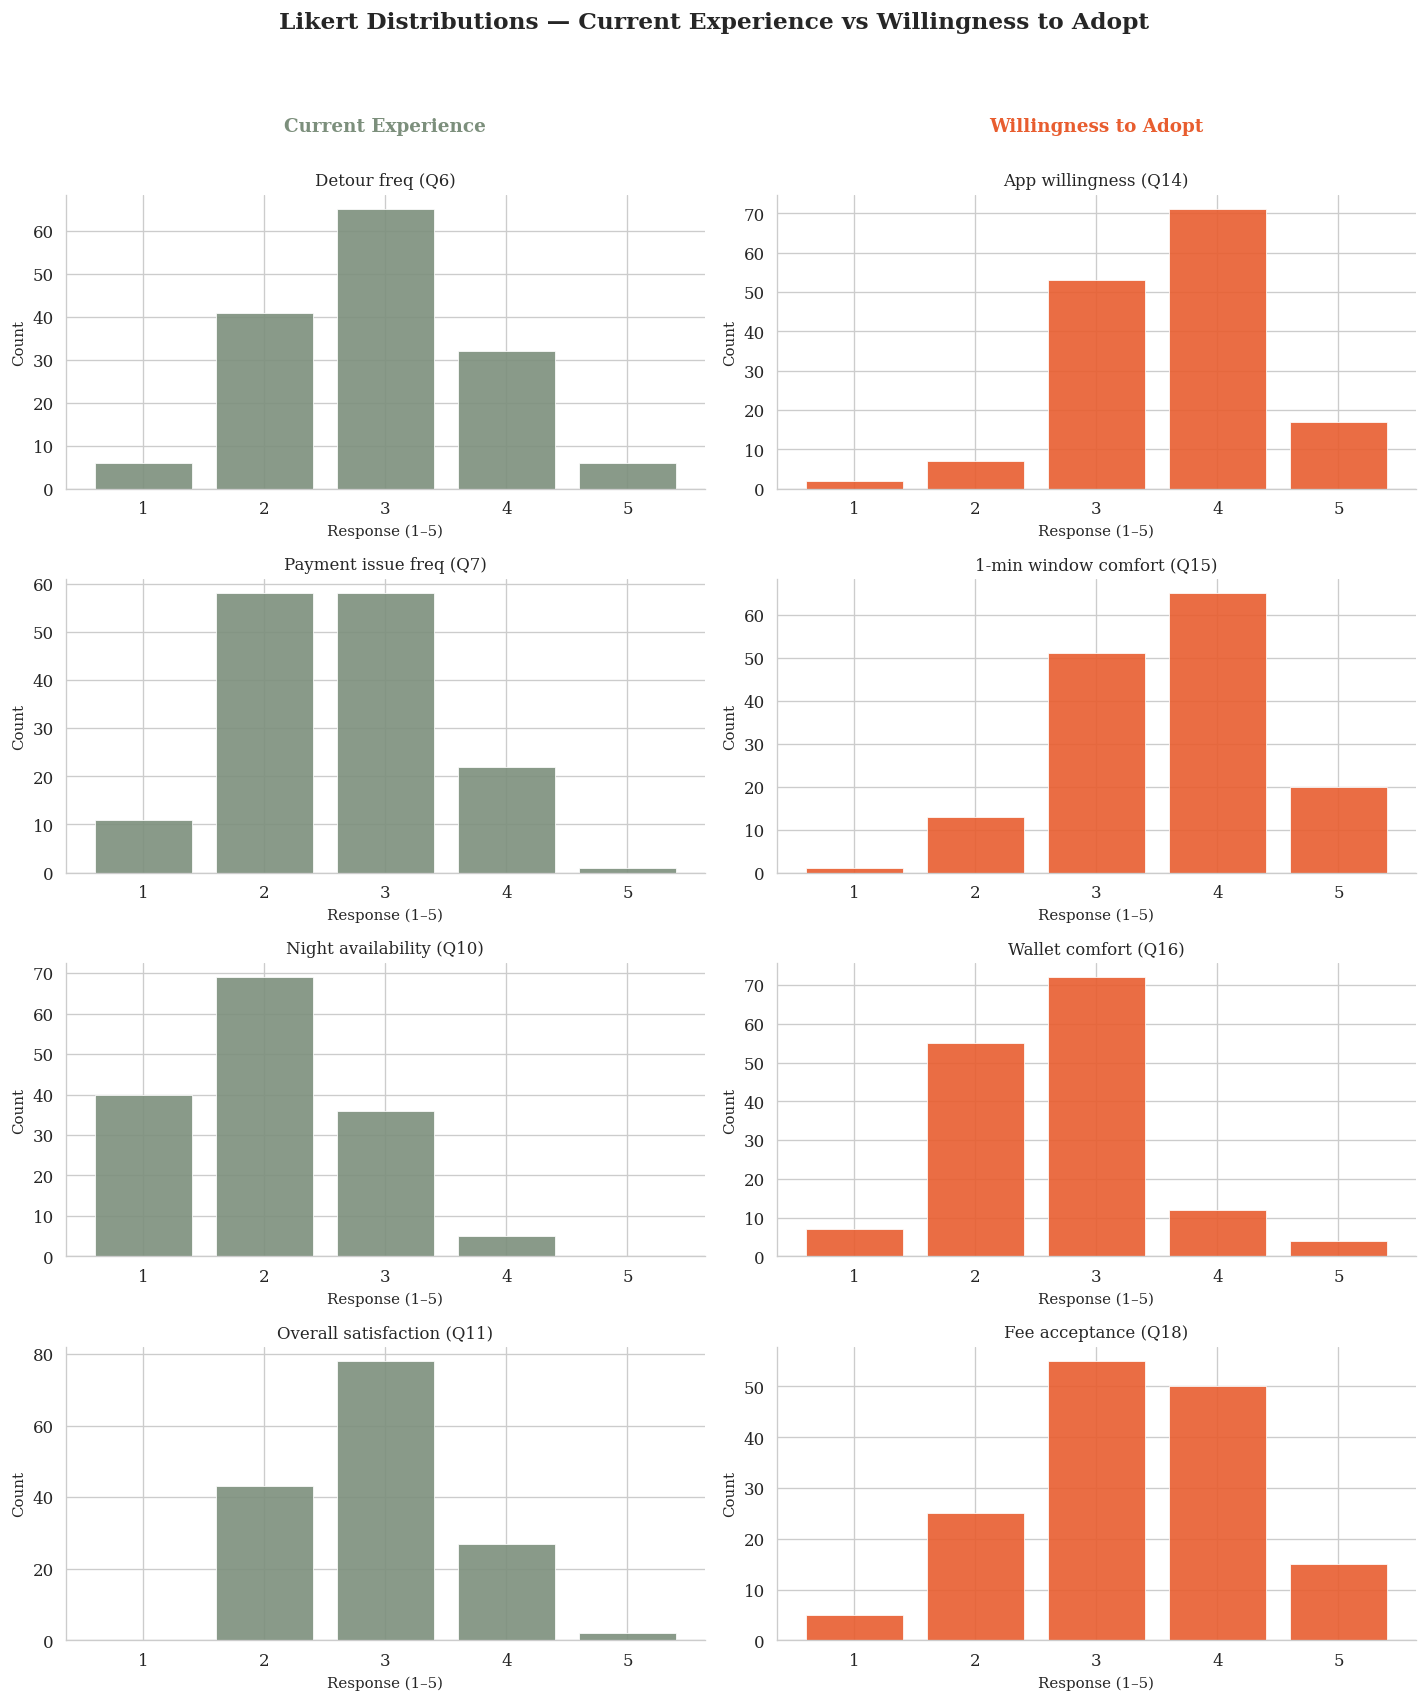

In [5]:
current_cols = [
    ('q6_detour_freq',           'Detour freq (Q6)'),
    ('q7_payment_issue_freq',    'Payment issue freq (Q7)'),
    ('q10_night_availability',   'Night availability (Q10)'),
    ('q11_overall_satisfaction', 'Overall satisfaction (Q11)'),
]
willingness_cols = [
    ('q14_app_willingness',      'App willingness (Q14)'),
    ('q15_1min_window_comfort',  '1-min window comfort (Q15)'),
    ('q16_wallet_comfort',       'Wallet comfort (Q16)'),
    ('q18_fee_acceptance',       'Fee acceptance (Q18)'),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharey=False)
fig.suptitle('Likert Distributions — Current Experience vs Willingness to Adopt',
             fontsize=14, y=1.01, fontweight='bold')
values = [1, 2, 3, 4, 5]

for row_idx in range(4):
    col, title = current_cols[row_idx]
    ax = axes[row_idx][0]
    cts = [(df[col] == v).sum() for v in values]
    ax.bar(values, cts, color=SAGE, edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Response (1–5)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_xticks(values)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    col2, title2 = willingness_cols[row_idx]
    ax2 = axes[row_idx][1]
    cts2 = [(df[col2] == v).sum() for v in values]
    ax2.bar(values, cts2, color=TERRA, edgecolor='white', linewidth=0.5, alpha=0.9)
    ax2.set_title(title2, fontsize=10)
    ax2.set_xlabel('Response (1–5)', fontsize=9)
    ax2.set_ylabel('Count', fontsize=9)
    ax2.set_xticks(values)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

axes[0][0].annotate('Current Experience', xy=(0.5, 1.22), xycoords='axes fraction',
                     ha='center', fontsize=11, color=SAGE, fontweight='bold')
axes[0][1].annotate('Willingness to Adopt', xy=(0.5, 1.22), xycoords='axes fraction',
                     ha='center', fontsize=11, color=TERRA, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.98])
out = os.path.join(CHART_DIR, 'likert_distributions.png')
fig.savefig(out, bbox_inches='tight')
print(f"Saved: {out}")
plt.show()


## 5. Wallet Willingness vs Top-Up Amount

Q16 asked how comfortable respondents would be maintaining an in-app digital wallet, while Q17 asked how much they would typically top-up at one time. Together these two items define the economic feasibility window for the wallet feature.

Saved: /home/pratham/pratham/QM_project/deliverables/survey/charts/wallet_willingness_bar.png


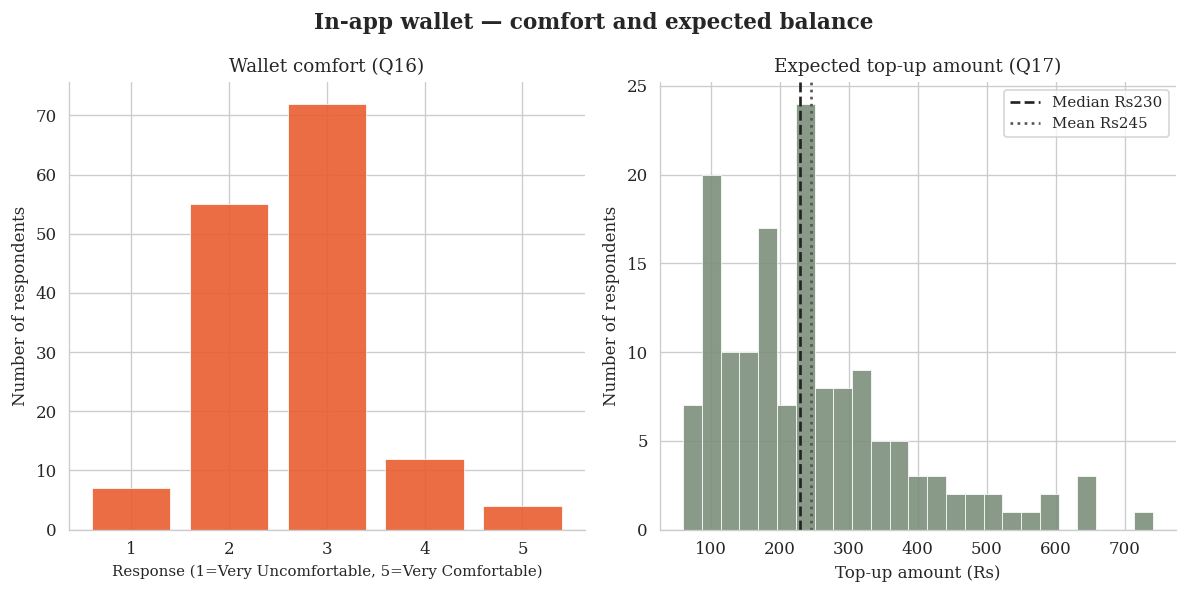

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('In-app wallet — comfort and expected balance', fontsize=13, fontweight='bold')

values = [1, 2, 3, 4, 5]
cts    = [(df['q16_wallet_comfort'] == v).sum() for v in values]
ax1.bar(values, cts, color=TERRA, edgecolor='white', linewidth=0.5, alpha=0.9)
ax1.set_title('Wallet comfort (Q16)', fontsize=11)
ax1.set_xlabel('Response (1=Very Uncomfortable, 5=Very Comfortable)', fontsize=9)
ax1.set_ylabel('Number of respondents', fontsize=10)
ax1.set_xticks(values)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

topup  = df['q17_topup_amount']
med_t  = topup.median()
mean_t = topup.mean()
ax2.hist(topup, bins=25, color=SAGE, edgecolor='white', linewidth=0.5, alpha=0.9)
ax2.axvline(med_t,  color='#222222', linestyle='--', linewidth=1.6, label=f'Median Rs{med_t:.0f}')
ax2.axvline(mean_t, color='#555555', linestyle=':',  linewidth=1.6, label=f'Mean Rs{mean_t:.0f}')
ax2.set_title('Expected top-up amount (Q17)', fontsize=11)
ax2.set_xlabel('Top-up amount (Rs)', fontsize=10)
ax2.set_ylabel('Number of respondents', fontsize=10)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
out = os.path.join(CHART_DIR, 'wallet_willingness_bar.png')
fig.savefig(out, bbox_inches='tight')
print(f"Saved: {out}")
plt.show()


## 6. Correlation Heatmap — The 'Pain Leads to Openness' Pattern

The heatmap below shows Pearson correlations among the nine key numeric variables. Overall satisfaction (Q11) has been negated so that higher values in the matrix consistently mean "more pain / more dissatisfied." A strong positive correlation between any pain column and any willingness column would validate the central TQM hypothesis: students who experience the most friction are also the most receptive to the proposed solution.

Saved: /home/pratham/pratham/QM_project/deliverables/survey/charts/correlation_heatmap.png


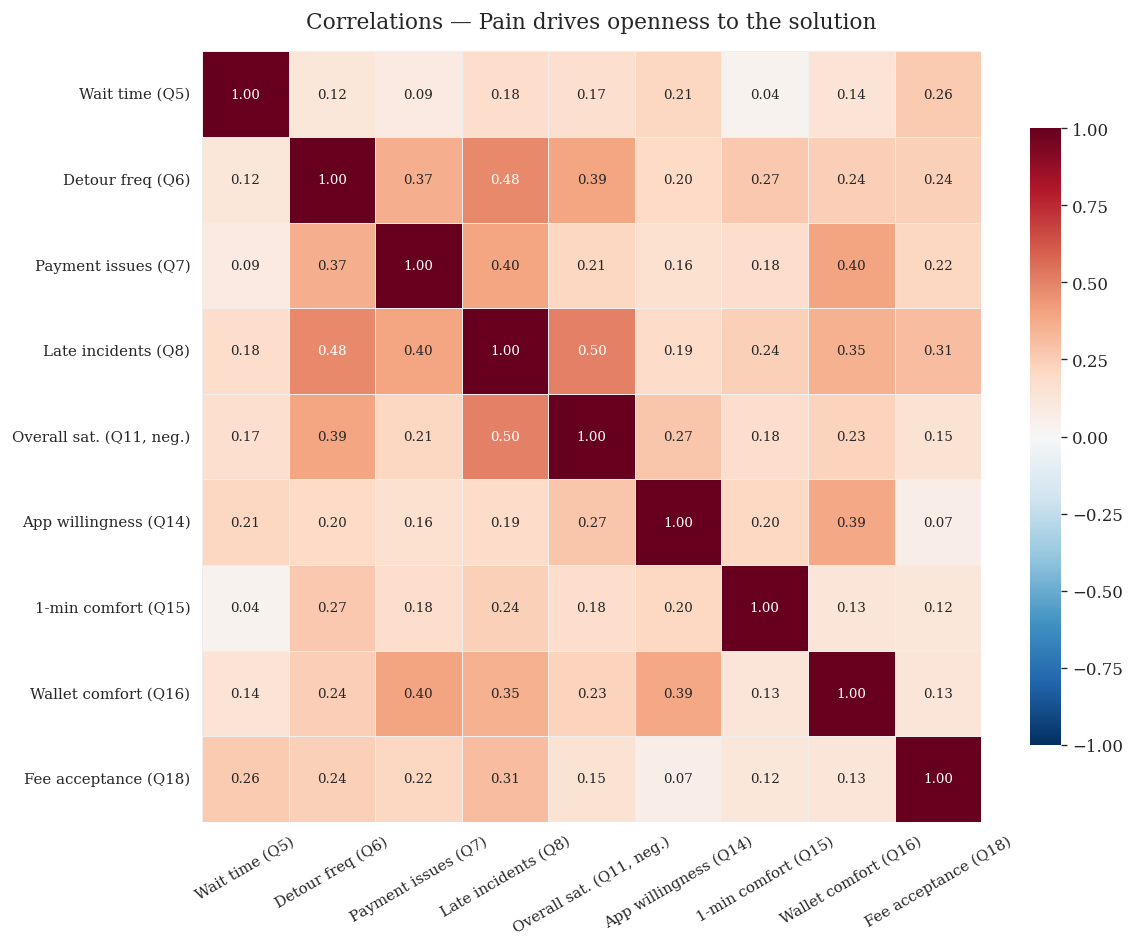


r(payment issues, wallet comfort) = 0.404
r(wait time, app willingness)     = 0.212


In [7]:
corr_cols = [
    'q5_wait_minutes', 'q6_detour_freq', 'q7_payment_issue_freq',
    'q8_late_incidents', 'q11_overall_satisfaction',
    'q14_app_willingness', 'q15_1min_window_comfort',
    'q16_wallet_comfort', 'q18_fee_acceptance',
]
label_map = {
    'q5_wait_minutes'         : 'Wait time (Q5)',
    'q6_detour_freq'          : 'Detour freq (Q6)',
    'q7_payment_issue_freq'   : 'Payment issues (Q7)',
    'q8_late_incidents'       : 'Late incidents (Q8)',
    'q11_overall_satisfaction': 'Overall sat. (Q11, neg.)',
    'q14_app_willingness'     : 'App willingness (Q14)',
    'q15_1min_window_comfort' : '1-min comfort (Q15)',
    'q16_wallet_comfort'      : 'Wallet comfort (Q16)',
    'q18_fee_acceptance'      : 'Fee acceptance (Q18)',
}
corr_df = df[corr_cols].copy()
corr_df['q11_overall_satisfaction'] = -corr_df['q11_overall_satisfaction']
corr_matrix = corr_df.rename(columns=label_map).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#eeeeee', ax=ax,
    annot_kws={'size': 8}, cbar_kws={'shrink': 0.8},
)
ax.set_title('Correlations — Pain drives openness to the solution', fontsize=13, pad=14)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
out = os.path.join(CHART_DIR, 'correlation_heatmap.png')
fig.savefig(out, bbox_inches='tight')
print(f"Saved: {out}")
plt.show()

# Key correlation
rho_pw = df['q7_payment_issue_freq'].corr(df['q16_wallet_comfort'])
rho_ww = df['q5_wait_minutes'].corr(df['q14_app_willingness'])
print(f"\nr(payment issues, wallet comfort) = {rho_pw:.3f}")
print(f"r(wait time, app willingness)     = {rho_ww:.3f}")


## 7. Findings Summary

Key findings drawn directly from the 150-respondent dataset:

- **Mean wait time** during peak hours is **8.2 minutes** (median 7 min); the 90th percentile respondent waits 13+ minutes, indicating a heavy right tail.
- **Top 3 pain points** — long wait (90 mentions, 60%), payment issues (71 mentions, 47%), and no night availability (66 mentions, 44%) — account for **56.8%** of all issue mentions combined.
- **Average app willingness** (Q14) is **3.63/5**, indicating a lean toward adoption without strong resistance.
- **Payment issues correlate positively with wallet comfort** (r = 0.404): respondents who experience more payment friction are more, not less, open to a digital wallet — a counter-intuitive but important validation of the solution design.
- **43.3%** of respondents rate the Rs5 cancellation fee as acceptable (4 or 5 out of 5), suggesting majority acceptance is attainable with appropriate communication.
- The **median expected wallet top-up is Rs230**, providing a realistic float-sizing benchmark for the app design team.


In [8]:
# ── Summary statistics ────────────────────────────────────────────────────
wait    = df['q5_wait_minutes']
mean_w  = wait.mean()
med_w   = wait.median()
p90_w   = wait.quantile(0.9)

raw_issues = []
for row in df['q12_issues_faced']:
    for item in str(row).split(';'):
        item = item.strip()
        if item and item != 'nan' and item != 'none_of_these':
            raw_issues.append(item)
issue_cnt = Counter(raw_issues)
top3      = issue_cnt.most_common(3)
total_m   = sum(issue_cnt.values())
top3_pct  = sum(v for _, v in top3) / total_m * 100

avg_app_will      = df['q14_app_willingness'].mean()
rho_payment_wallet = df['q7_payment_issue_freq'].corr(df['q16_wallet_comfort'])
fee_accept_pct    = (df['q18_fee_acceptance'] >= 4).sum() / len(df) * 100
med_topup         = df['q17_topup_amount'].median()
mean_topup        = df['q17_topup_amount'].mean()

print("=" * 58)
print("SURVEY SUMMARY STATISTICS  (n = 150)")
print("=" * 58)
print(f"  Mean wait time (peak hours)          : {mean_w:.1f} min")
print(f"  Median wait time (peak hours)        : {med_w:.1f} min")
print(f"  90th-pct wait time                   : {p90_w:.0f} min")
print(f"  Top 3 pain points (% of all mentions): {top3_pct:.1f}%")
for rank, (issue, cnt_v) in enumerate(top3, 1):
    pct_resp = cnt_v / len(df) * 100
    print(f"    {rank}. {issue}: {cnt_v} respondents ({pct_resp:.0f}%)")
print(f"  Avg app willingness (Q14, /5)        : {avg_app_will:.2f}")
print(f"  r(payment issues, wallet comfort)    : {rho_payment_wallet:.3f}")
print(f"  Fee acceptance rate (rating 4-5)     : {fee_accept_pct:.1f}%")
print(f"  Median expected top-up (Q17)         : Rs{med_topup:.0f}")
print(f"  Mean expected top-up (Q17)           : Rs{mean_topup:.0f}")
print("=" * 58)


SURVEY SUMMARY STATISTICS  (n = 150)
  Mean wait time (peak hours)          : 8.2 min
  Median wait time (peak hours)        : 7.0 min
  90th-pct wait time                   : 13 min
  Top 3 pain points (% of all mentions): 56.8%
    1. long_wait: 90 respondents (60%)
    2. payment_issue: 71 respondents (47%)
    3. no_night_availability: 66 respondents (44%)
  Avg app willingness (Q14, /5)        : 3.63
  r(payment issues, wallet comfort)    : 0.404
  Fee acceptance rate (rating 4-5)     : 43.3%
  Median expected top-up (Q17)         : Rs230
  Mean expected top-up (Q17)           : Rs245
